# Illustration 7.5-3 &mdash; vapor pressure of water from the Peng&ndash;Robinson equation

Sections 7.4 and 7.5 built one machine: given an equation of state, find the pressure at
which liquid and vapor fugacities are equal. [`vapor_pressure_n_butane.ipynb`
](vapor_pressure_n_butane.ipynb) ran it for *n*-butane and [`vapor_pressure_oxygen.ipynb`
](vapor_pressure_oxygen.ipynb) for oxygen &mdash; a hydrocarbon and an inorganic gas, the
two families the generalized Peng&ndash;Robinson parameters were built for. Both worked
well.

**Illustration 7.5-3 runs the same machine on water, and it does not work well.** That is
the point of the illustration, and of the paragraph that precedes it:

> It must be emphasized that the generalization of the Peng-Robinson equation-of-state
> parameters given by Eqs. 6.7-2, 6.7-3, and 6.7-4 is useful only for hydrocarbons and
> inorganic gases (O$_2$, N$_2$, CO$_2$, etc.). For polar fluids (water, organic acids,
> alcohols, etc.), this simple generalization is not accurate, especially at low
> temperatures and pressures.

The fix introduced here is **PRSV** &mdash; Peng&ndash;Robinson with the
Stryjek&ndash;Vera modification, which replaces the generalized $\kappa(\omega)$ of
Eq. 6.7-4 with a form carrying one fluid-specific constant $\kappa_1$. This notebook
computes all four columns of the illustration's table:

| column | equation of state |
|---|---|
| steam tables | the measured values, Appendix A.III |
| PR $\alpha(T)$ | Peng&ndash;Robinson, generalized $\kappa(\omega)$ |
| PR $\alpha = 1$ | the temperature dependence switched off, for contrast |
| PRSV | Stryjek&ndash;Vera, $\kappa_1 = -0.0665$ |

and then asks the questions the table implies but does not answer: *how* much better is
PRSV, *where* is it better, and *why*.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst  
August 2026

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

## Water, and why it is hard

The critical constants and acentric factor are the SIS Table 6.6-1 values. Nothing about
them looks unusual &mdash; the trouble is not in the numbers but in what the generalized
correlation assumes about the molecule.

The Peng&ndash;Robinson $\kappa(\omega)$ of Eq. 6.7-4 was fitted to hydrocarbons. It
carries exactly one piece of information about the substance beyond its critical point:
the acentric factor $\omega$, which measures how far the molecule departs from a
spherical, non-polar one. Water departs in a way $\omega$ cannot express &mdash; it
hydrogen-bonds. Two water molecules attract each other with a strong, *directional*
interaction that has no counterpart in a fluid of spheres, and the temperature dependence
that produces in the attraction parameter $a(T)$ is not the temperature dependence a
one-parameter correlation fitted to alkanes will reproduce.

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants
from scipy.optimize import brentq
from numpy.polynomial import Polynomial

# Typography, matching the other recomputed figures: use a real LaTeX installation when
# there is one, so anything plotted is set in Computer Modern like the book, and fall back
# to matplotlib's own mathtext otherwise — the notebook still runs in Colab, which has no
# TeX. The fallback keeps a serif face and CM math.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

R = constants.R          # J/(mol K)
SQRT2 = np.sqrt(2.0)
TO_KELVIN = 273.15

# water — SIS Table 6.6-1
Tc = 647.3               # K
Pc = 220.48e5            # Pa
omega = 0.344            # acentric factor

KAPPA_1 = -0.0665        # the fluid-specific PRSV constant for water (Illustration 7.5-3)

print(f"water: Tc = {Tc} K ({Tc - TO_KELVIN:.1f} C), Pc = {Pc/1e5:.2f} bar, "
      f"omega = {omega}")
print(f"for comparison — n-butane omega = 0.199, oxygen omega = 0.021")

water: Tc = 647.3 K (374.1 C), Pc = 220.48 bar, omega = 0.344
for comparison — n-butane omega = 0.199, oxygen omega = 0.021


## Three ways to set $\alpha(T)$

All three columns use the *same* Peng&ndash;Robinson equation,

$$ P = \frac{RT}{\underline{V}-b} -
   \frac{a(T)}{\underline{V}(\underline{V}+b) + b(\underline{V}-b)}, \qquad
   b = 0.07780\,\frac{RT_c}{P_c}, \qquad
   a(T) = 0.45724\,\frac{R^{2}T_c^{2}}{P_c}\,\alpha(T) $$

and the same equal-fugacity condition. They differ only in $\alpha$:

$$ \sqrt{\alpha} = 1 + \kappa\left(1 - \sqrt{T_r}\right), \qquad T_r = T/T_c $$

**PR, generalized** (Eq. 6.7-4) &mdash; one correlation for all fluids, keyed on $\omega$:

$$ \kappa = 0.37464 + 1.54226\,\omega - 0.26992\,\omega^{2} $$

**PR with $\alpha = 1$** &mdash; the attraction frozen at its critical-point value. Not a
serious model; it is in the table to show what the temperature dependence is worth.

**PRSV** (Eqs. 7.5-1 and 7.5-2) &mdash; Stryjek and Vera replace that $\kappa$ with

$$ \kappa = \kappa_0 + \kappa_1\left(1 + T_r^{0.5}\right)\left(0.7 - T_r\right) $$
$$ \kappa_0 = 0.378893 + 1.4897153\,\omega - 0.17131848\,\omega^{2}
   + 0.0196554\,\omega^{3} $$

where $\kappa_1$ is fitted per fluid to low-temperature vapor pressures &mdash; for water,
$-0.0665$.

Look at the structure of the $\kappa_1$ term before computing anything. It is proportional
to $(0.7 - T_r)$, so it **vanishes identically at $T_r = 0.7$** and grows as the
temperature falls below that. Stryjek and Vera built the correction to be a
*low-temperature* correction and to leave the high-temperature behaviour alone. Watch for
$T_r = 0.7$ in the results.

> Coefficients as given by R. Stryjek and J. H. Vera, *Can. J. Chem. Eng.* **64**, 323 and
> 820 (1986).

In [3]:
b_PR = 0.07780 * R * Tc / Pc
A_PR = 0.45724 * R**2 * Tc**2 / Pc

kappa_PR = 0.37464 + 1.54226 * omega - 0.26992 * omega**2
kappa_0 = (0.378893 + 1.4897153 * omega - 0.17131848 * omega**2
           + 0.0196554 * omega**3)


def kappa(model, T):
    """kappa for each of the three columns. `one` never uses it."""
    if model == "pr":
        return kappa_PR
    Tr = T / Tc
    return kappa_0 + KAPPA_1 * (1 + np.sqrt(Tr)) * (0.7 - Tr)      # Eq. 7.5-1


def a_of_T(model, T):
    if model == "one":
        return A_PR                                   # alpha = 1
    return A_PR * (1 + kappa(model, T) * (1 - np.sqrt(T / Tc)))**2


MODELS = {"pr": r"PR, $\alpha(T)$", "one": r"PR, $\alpha = 1$", "prsv": "PRSV"}

print(f"kappa   (PR, Eq. 6.7-4)  = {kappa_PR:.5f}")
print(f"kappa_0 (PRSV, Eq. 7.5-2) = {kappa_0:.5f}")
print(f"\nThe two differ by only {100*abs(kappa_0-kappa_PR)/kappa_PR:.2f}% — so essentially "
      f"none of the\nimprovement below comes from kappa_0. It all comes from the "
      f"kappa_1 term.")
print(f"\nThat term vanishes at Tr = 0.7, i.e. T = {0.7*Tc:.1f} K = {0.7*Tc-TO_KELVIN:.1f} C,"
      f"\nwhere PRSV and PR must give the same answer.")

kappa   (PR, Eq. 6.7-4)  = 0.87324
kappa_0 (PRSV, Eq. 7.5-2) = 0.87188

The two differ by only 0.16% — so essentially none of the
improvement below comes from kappa_0. It all comes from the kappa_1 term.

That term vanishes at Tr = 0.7, i.e. T = 453.1 K = 180.0 C,
where PRSV and PR must give the same answer.


## The saturation calculation

Unchanged from the *n*-butane and oxygen notebooks: the vapor pressure is the one pressure
at which $f^{L} = f^{V}$, and the root is **bracketed between the two spinodal pressures**
rather than guessed, so the trivial solution Sec. 7.5 warns about is unreachable. Written
once and handed each of the three $\alpha$ models in turn, which is what makes the
comparison a controlled one.

In [4]:
def real_roots(P, T, model):
    """Real compressibility roots above B, with A and B."""
    a = a_of_T(model, T)
    A, B = a * P / (R * T)**2, b_PR * P / (R * T)
    roots = Polynomial([-A * B + B**2 + B**3, A - 3 * B**2 - 2 * B, -1 + B, 1]).roots()
    keep = np.abs(roots.imag) < 1e-9 * np.maximum(1.0, np.abs(roots.real))
    Z = np.sort(roots.real[keep])
    return Z[Z > B], A, B


def ln_phi(Z, A, B):
    return (Z - 1) - np.log(Z - B) - A / (2 * SQRT2 * B) * \
        np.log((Z + (1 + SQRT2) * B) / (Z + (1 - SQRT2) * B))


def spinodal_bounds(model, T, n=20000):
    """Pressures at the local max and min of the sub-critical isotherm loop."""
    a = a_of_T(model, T)
    V = np.logspace(np.log10(1.0000001 * b_PR), 3.0, n)
    P = R * T / (V - b_PR) - a / (V * (V + b_PR) + b_PR * (V - b_PR))
    turns = np.where(np.diff(np.sign(np.diff(P))) != 0)[0]
    if len(turns) < 2:
        return None
    return P[turns].min(), P[turns].max()


def residual(model, T, P):
    Z, A, B = real_roots(P, T, model)
    if len(Z) < 2:
        return np.nan
    return ln_phi(Z.min(), A, B) - ln_phi(Z.max(), A, B)


def Psat(model, T):
    """Vapor pressure (Pa) at T (K) for one of the three models."""
    bounds = spinodal_bounds(model, T)
    if bounds is None:
        return None
    P_lo, P_hi = bounds
    P_lo = max(P_lo, 1e-12)
    for _ in range(300):
        r_lo, r_hi = residual(model, T, P_lo), residual(model, T, P_hi)
        if np.isfinite(r_lo) and np.isfinite(r_hi) and r_lo * r_hi < 0:
            break
        if not np.isfinite(r_lo):
            P_lo *= 1.5
        if not np.isfinite(r_hi):
            P_hi *= 0.999
        if P_hi <= P_lo:
            return None
    else:
        return None
    return brentq(lambda P: residual(model, T, P), P_lo, P_hi, xtol=1e-12, rtol=1e-12)


# sanity check: the normal boiling point should come out near 1 atm
print(f"{'model':<16}{'Psat(373.15 K), kPa':>22}")
for m in MODELS:
    print(f"{MODELS[m].replace('$','').replace(chr(92)+'alpha','alpha'):<16}"
          f"{Psat(m, 373.15)/1e3:22.2f}")
print(f"{'measured':<16}{constants.atm/1e3:22.2f}")

model              Psat(373.15 K), kPa
PR, alpha(T)                     96.00
PR, alpha = 1                  1233.82
PRSV                            101.07
measured                        101.33


## The reference column: the steam tables

The measured vapor pressures are the saturation values from the **steam tables, SIS
Appendix A.III** &mdash; the same source the illustration compares against. Water is the
one fluid in this book with reference-quality data behind it: as Illustration 7.5-2's
closing note points out, the steam tables rest on an equation with 59 substance-specific
constants fitted to a very large body of careful measurement. That is what makes water the
right test case here. A three-parameter cubic has nowhere to hide.

The temperatures are the fifteen of the illustration, running from the triple point
(273.16 K) to 643.15 K &mdash; within 4 K of the critical temperature.

In [5]:
# Vapor pressure of water, SIS Appendix A.III (saturated steam tables). T in K, P in kPa.
data = pd.DataFrame({
    "T": [273.16, 283.15, 293.15, 303.15, 323.15, 343.15, 373.15, 393.15,
          423.15, 448.15, 473.15, 523.15, 573.15, 623.15, 643.15],
    "steam": [0.6113, 1.2276, 2.339, 4.246, 12.35, 31.19, 101.4, 198.5,
              475.8, 892.0, 1554.0, 3973.0, 8581.0, 16513.0, 21030.0],
})
data["Tr"] = data["T"] / Tc
data["t_C"] = data["T"] - TO_KELVIN

print(f"{len(data)} temperatures, {data['T'].min():.2f}-{data['T'].max():.2f} K "
      f"(Tr = {data['Tr'].min():.3f} to {data['Tr'].max():.3f})")
print(f"vapor pressures span {data['steam'].min():.4f} to {data['steam'].max():.0f} kPa "
      f"— a factor of {data['steam'].max()/data['steam'].min():.0f}\n")

# Two internal checks on the reference column.
i100 = data.index[data["T"] == 373.15][0]
print(f"at 373.15 K the table gives {data['steam'][i100]} kPa, against "
      f"1 atm = {constants.atm/1e3:.3f} kPa")
i_tp = 0
print(f"at 273.16 K (the triple point) it gives {data['steam'][i_tp]} kPa, "
      f"the triple-point pressure")

15 temperatures, 273.16-643.15 K (Tr = 0.422 to 0.994)
vapor pressures span 0.6113 to 21030 kPa — a factor of 34402

at 373.15 K the table gives 101.4 kPa, against 1 atm = 101.325 kPa
at 273.16 K (the triple point) it gives 0.6113 kPa, the triple-point pressure


### An independent check on the reference column

The book's property database carries a Wagner vapor-pressure correlation for water fitted
over 275&ndash;647 K (`code/data/pure_property.csv`, the digitized Appendix A). It is an
entirely separate correlation from the steam tables, so agreement between the two is a
check that the numbers above were transcribed correctly &mdash; worth doing before using
them to judge three equations of state.

In [6]:
import sys
sys.path.insert(0, "..")            # so `thermo` resolves when run from code/ch7/
from thermo.data import get_compound

row = get_compound("water")
wa, wb, wc, wd = row["VpA"], row["VpB"], row["VpC"], row["VpD"]


def P_wagner(T):
    """Vapor pressure (Pa) from the pure_property.csv Wagner constants (Eq = 1)."""
    t = 1 - np.asarray(T, dtype=float) / row["Tc"]
    return row["Pc"] * 1e5 * np.exp(
        (wa * t + wb * t**1.5 + wc * t**3 + wd * t**6) / (1 - t))


err_w = 100 * (P_wagner(data["T"]) / (data["steam"] * 1e3) - 1)
print(f"Wagner correlation vs the steam-table column (fitted {row['Tmin']:.0f}-"
      f"{row['Tmax']:.0f} K):\n")
print(f"{'T (K)':>8}{'steam':>11}{'Wagner':>11}{'diff %':>9}")
for T, s, e in zip(data["T"], data["steam"], err_w):
    print(f"{T:8.2f}{s:11.4g}{P_wagner(T)/1e3:11.4g}{e:+9.2f}")

print(f"\n  mean |difference| {np.abs(err_w).mean():.2f}%, worst "
      f"{np.abs(err_w).max():.2f}% at {data['T'][np.abs(err_w).idxmax()]:.2f} K")
print(f"""
Two independent correlations agreeing to a tenth of a percent over 370 K and four
decades of pressure. The steam-table column is transcribed correctly, and the models
below are being judged against a reference that is far more accurate than any of them.

(The first point, {data['T'][0]:.2f} K, sits just below the Wagner fit's stated lower limit
of {row['Tmin']:.0f} K, so it is a short extrapolation — and it agrees to {abs(err_w[0]):.2f}% anyway.)""")

Wagner correlation vs the steam-table column (fitted 275-647 K):

   T (K)      steam     Wagner   diff %
  273.16     0.6113      0.612    +0.11
  283.15      1.228      1.229    +0.11
  293.15      2.339      2.341    +0.07
  303.15      4.246      4.249    +0.06
  323.15      12.35      12.35    +0.01
  343.15      31.19      31.19    -0.01
  373.15      101.4      101.4    -0.02
  393.15      198.5      198.7    +0.08
  423.15      475.8      476.4    +0.13
  448.15        892      893.4    +0.16
  473.15       1554       1557    +0.16
  523.15       3973       3979    +0.16
  573.15       8581       8594    +0.16
  623.15  1.651e+04  1.655e+04    +0.22
  643.15  2.103e+04  2.105e+04    +0.12

  mean |difference| 0.10%, worst 0.22% at 623.15 K

Two independent correlations agreeing to a tenth of a percent over 370 K and four
decades of pressure. The steam-table column is transcribed correctly, and the models
below are being judged against a reference that is far more accurate than 

## Table 7.5-3

All four columns, plus what the illustration's table leaves to the eye: the percentage
error of each model against the steam tables.

In [7]:
for m in MODELS:
    data[m] = [Psat(m, T) / 1e3 for T in data["T"]]
    data[f"{m}_err"] = 100 * (data[m] - data["steam"]) / data["steam"]

show = data[["T", "t_C", "Tr", "steam", "pr", "one", "prsv"]].copy()
show.columns = ["T (K)", "t (C)", "Tr", "steam tables", "PR a(T)", "PR a=1", "PRSV"]
print("vapor pressure of water (kPa)\n")
print(show.to_string(index=False, formatters={
    "T (K)": "{:.2f}".format, "t (C)": "{:.1f}".format, "Tr": "{:.3f}".format,
    "steam tables": "{:.4g}".format, "PR a(T)": "{:.4g}".format,
    "PR a=1": "{:.4g}".format, "PRSV": "{:.4g}".format}))

err = data[["T", "Tr", "pr_err", "one_err", "prsv_err"]].copy()
err.columns = ["T (K)", "Tr", "PR a(T) %", "PR a=1 %", "PRSV %"]
print("\n\nerror against the steam tables\n")
print(err.to_string(index=False, formatters={
    "T (K)": "{:.2f}".format, "Tr": "{:.3f}".format, "PR a(T) %": "{:+.2f}".format,
    "PR a=1 %": "{:+.1f}".format, "PRSV %": "{:+.2f}".format}))

print(f"\n{'model':<12}{'mean |error|':>14}{'worst':>12}{'worst at':>12}")
for m in MODELS:
    e = data[f"{m}_err"].abs()
    print(f"{m:<12}{e.mean():13.2f}%{e.max():11.1f}%{data['T'][e.idxmax()]:11.2f} K")

vapor pressure of water (kPa)

 T (K) t (C)    Tr steam tables   PR a(T)    PR a=1      PRSV
273.16   0.0 0.422       0.6113    0.4829     121.7    0.6097
283.15  10.0 0.437        1.228    0.9973     164.8     1.224
293.15  20.0 0.453        2.339     1.948     218.7      2.33
303.15  30.0 0.468        4.246     3.618     284.9     4.231
323.15  50.0 0.499        12.35     10.94     460.8      12.3
343.15  70.0 0.530        31.19     28.51     706.1     31.09
373.15 100.0 0.576        101.4        96      1234     101.1
393.15 120.0 0.607        198.5     191.4      1712       198
423.15 150.0 0.654        475.8     467.5      2653     474.6
448.15 175.0 0.692          892     886.1      3668     889.6
473.15 200.0 0.731         1554      1555      4921      1550
523.15 250.0 0.808         3973      4012      8228      3971
573.15 300.0 0.885         8581      8691 1.275e+04      8604
623.15 350.0 0.963    1.651e+04 1.665e+04 1.865e+04 1.658e+04
643.15 370.0 0.994    2.103e+04 2.104e+

### What the numbers say

**The generalized Peng&ndash;Robinson equation is not good enough for water.** It is 21%
low at the triple point and averages 7% across the range. Compare that with the same
equation applied to *n*-butane or oxygen, where the complete Peng&ndash;Robinson equation
tracked the data to a few percent everywhere. Nothing changed in the method; only the
molecule did.

**Freezing $\alpha$ is catastrophic, not merely poor.** At 273 K the $\alpha = 1$ column
predicts 122 kPa against a measured 0.61 &mdash; a factor of 200. This column exists to
make a point the chapter has now made twice, in Figure 7.5-2 for *n*-butane and again
here: the temperature dependence of $a$ is not a refinement, it is most of what a cubic
equation of state knows about vapor pressure.

**One fitted constant buys a factor of 26.** PRSV's mean error is 0.27% against
Peng&ndash;Robinson's 7.05%, and it never exceeds 0.4% anywhere in the table. That is the
illustration's conclusion, and it is worth being precise about what kind of success it is:
$\kappa_1$ was *fitted to low-temperature vapor pressures for water*. PRSV agreeing with
water's vapor pressure is a correlation doing what it was built to do &mdash; exactly as
with the $\alpha(T)$ form itself in Fig. 7.5-2. The honest claim is not that PRSV is a
better theory but that one substance-specific number, well placed, is worth more than any
amount of generalized correlation.

**And all three must agree at the critical point.** At 643.15 K ($T_r = 0.994$) every
column is within 2% of the data, including $\alpha = 1$. That is built in, not earned:
$\alpha(T_c) = 1$ by construction in all three, and all three use the same $T_c$ and $P_c$.
The differences between equations of state are always largest far from the critical point.

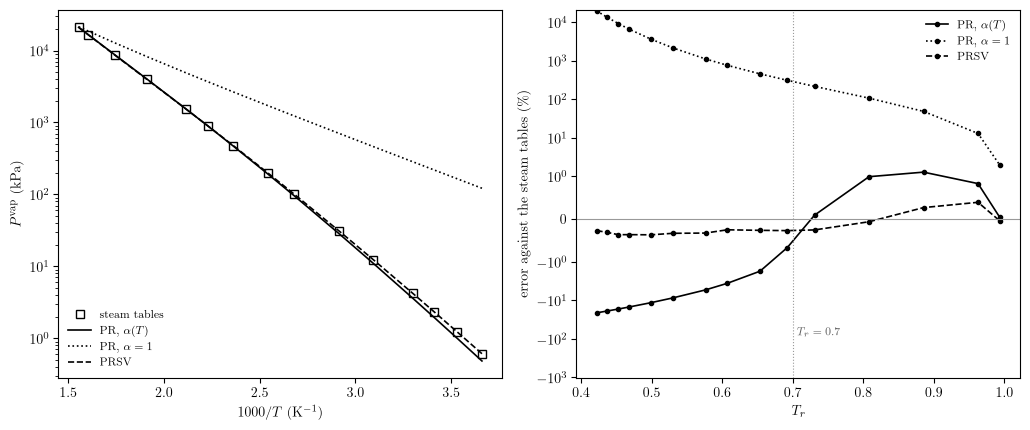

The right-hand panel is on a symmetric-log scale: linear within +/-1%, logarithmic
outside it, so PRSV's sub-percent errors and the alpha=1 column's 20000% are both visible.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.4, 4.4))

# --- left: the vapor pressures themselves, on Clausius-Clapeyron axes ---
inv = 1e3 / data["T"]
ax1.plot(inv, data["steam"], "s", mfc="none", mec="black", ms=6, mew=1.0,
         label="steam tables", zorder=3)
for m, style in zip(MODELS, ("-", ":", "--")):
    ax1.plot(inv, data[m], style, color="black", lw=1.2, label=MODELS[m])
ax1.set_yscale("log")
ax1.set_xlabel(r"$1000/T$  (K$^{-1}$)")
ax1.set_ylabel(r"$P^{\mathrm{vap}}$  (kPa)")
ax1.legend(frameon=False, fontsize=8, loc="lower left")

# --- right: the error, which is where the story is ---
for m, style in zip(MODELS, ("-", ":", "--")):
    ax2.plot(data["Tr"], data[f"{m}_err"], style, color="black", lw=1.2,
             marker="o", ms=3, label=MODELS[m])
ax2.axhline(0, color="0.6", lw=0.8)
ax2.axvline(0.7, color="0.6", lw=0.8, ls=":")
ax2.annotate(r"$T_r = 0.7$", xy=(0.7, -80), xytext=(3, 0), textcoords="offset points",
             fontsize=8, color="0.35")
ax2.set_yscale("symlog", linthresh=1)
ax2.set_xlabel(r"$T_r$")
ax2.set_ylabel(r"error against the steam tables (\%)"
               if mpl.rcParams["text.usetex"] else
               "error against the steam tables (%)")
ax2.legend(frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
plt.show()

print("The right-hand panel is on a symmetric-log scale: linear within +/-1%, "
      "logarithmic\noutside it, so PRSV's sub-percent errors and the alpha=1 "
      "column's 20000% are both visible.")

## Where PRSV's advantage comes from

The two $\kappa$ constants are almost the same number: 0.87324 for Peng&ndash;Robinson and
0.87188 for $\kappa_0$. So the entire improvement is the correction term
$\kappa_1(1 + \sqrt{T_r})(0.7 - T_r)$ &mdash; and that term is built to switch itself off.

Three consequences, all visible in the error table above:

1. At $T_r = 0.7$ the correction is exactly zero, so **PRSV and PR must agree there**.
   $T_r = 0.7$ is 453 K for water, and the two columns do converge between 448 and 473 K.
2. Peng&ndash;Robinson's error crosses zero at almost exactly the same place. That is a
   coincidence of this fluid, not a design feature &mdash; but it explains why the two
   models look interchangeable in the middle of the table and diverge at both ends.
3. Above $T_r = 0.7$ the correction reverses sign, since $(0.7 - T_r)$ goes negative. With
   $\kappa_1 < 0$ it therefore *raises* $\kappa$ at high temperature, which is why PRSV
   stays slightly better than PR near the critical point rather than merely matching it.

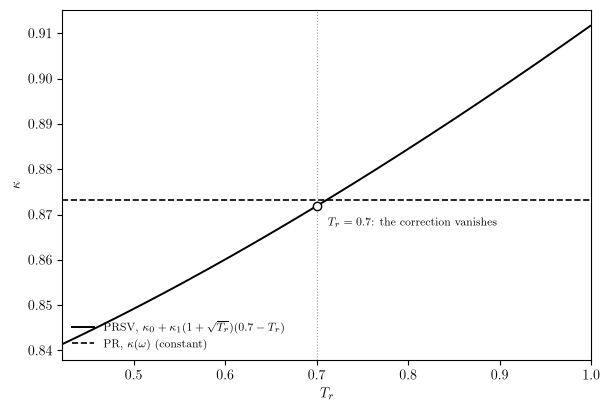

kappa at the coldest point (Tr = 0.422):  PR 0.8732   PRSV 0.8414   (-3.6%)
kappa at Tr = 0.7:                     PR 0.8732   PRSV 0.8719

A -3.6% change in kappa at the cold end moves the vapor pressure from
-21% to -0.3%. The vapor pressure is exponentially sensitive
to alpha — which is both why one fitted constant can do this much good, and why
getting alpha wrong is so expensive.


In [9]:
T_grid = np.linspace(273.15, 0.999 * Tc, 300)
Tr_grid = T_grid / Tc

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.plot(Tr_grid, [kappa("prsv", T) for T in T_grid], "-", color="black", lw=1.4,
        label=r"PRSV, $\kappa_0 + \kappa_1(1+\sqrt{T_r})(0.7-T_r)$")
ax.axhline(kappa_PR, color="black", lw=1.2, ls="--",
           label=r"PR, $\kappa(\omega)$ (constant)")
ax.axvline(0.7, color="0.6", lw=0.8, ls=":")
ax.plot([0.7], [kappa("prsv", 0.7 * Tc)], "o", mfc="white", mec="black", ms=6, mew=1.0,
        zorder=3)
ax.annotate(r"$T_r = 0.7$: the correction vanishes",
            xy=(0.7, kappa("prsv", 0.7 * Tc)), xytext=(8, -14),
            textcoords="offset points", fontsize=8)

ax.set_xlabel(r"$T_r$")
ax.set_ylabel(r"$\kappa$")
ax.set_xlim(Tr_grid.min(), 1.0)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

k_cold = kappa("prsv", data["T"].min())
d_kappa = 100 * (k_cold - kappa_PR) / kappa_PR
print(f"kappa at the coldest point (Tr = {data['Tr'].min():.3f}):  "
      f"PR {kappa_PR:.4f}   PRSV {k_cold:.4f}   ({d_kappa:+.1f}%)")
print(f"kappa at Tr = 0.7:                     "
      f"PR {kappa_PR:.4f}   PRSV {kappa('prsv', 0.7*Tc):.4f}")
print(f"""
A {d_kappa:+.1f}% change in kappa at the cold end moves the vapor pressure from
{data['pr_err'][0]:+.0f}% to {data['prsv_err'][0]:+.1f}%. The vapor pressure is exponentially sensitive
to alpha — which is both why one fitted constant can do this much good, and why
getting alpha wrong is so expensive.""")

## What this illustration shows

**A generalized correlation has a domain, and water is outside it.** The
Peng&ndash;Robinson $\kappa(\omega)$ is one curve fitted through hydrocarbons. Asking it
about a hydrogen-bonding liquid is asking it to extrapolate along an axis
($\omega$) that does not encode the thing that makes water different. The 21% error at the
triple point is not a numerical problem or a bad root &mdash; the calculation is exactly
the same one that worked to a few percent for *n*-butane. It is a modelling error, and no
amount of careful computing fixes it.

**The remedy is one number per fluid, in the right place.** $\kappa_1$ does not change the
form of the equation of state, the mixing of the cubic, the fugacity expression, or the
solution algorithm &mdash; only $\kappa$. And because it is multiplied by $(0.7 - T_r)$ it
touches only the region where the generalized form was failing. That is what a
well-designed correction looks like: local, cheap, and off by default.

**Which is why Chapter 10 uses PRSV for polar fluids.** The paragraph after this
illustration says so directly, and the reason is worth carrying forward: mixture
vapor&ndash;liquid equilibrium is computed from pure-component fugacities, so an error in
a pure component's vapor pressure propagates straight into the mixture prediction. A 21%
error in water's vapor pressure is not something a mixing rule can repair.

### Things to try

1. **Fit $\kappa_1$ yourself.** Take the steam-table column as data and find the
   $\kappa_1$ that minimises the error over the whole range, then over only $T_r < 0.7$
   (which is what Stryjek and Vera fitted). Do you recover $-0.0665$? Which fit is better
   near the critical point, and why might they have chosen the low-temperature one?
2. **Try another polar fluid.** Methanol, ethanol, and ammonia are all in
   `code/data/pure_property.csv` with Wagner correlations to compare against. How large is
   the generalized-PR error for each, and does it track anything you can name &mdash;
   dipole moment, hydrogen-bonding capacity, $\omega$?
3. **Check a fluid PR is supposed to handle.** Rerun the whole notebook for *n*-butane
   with $\kappa_1 = 0$. How much does PRSV differ from PR when the fluid is a
   well-behaved hydrocarbon? That difference is the price of using PRSV everywhere.
4. **Problem 7.58** asks for this illustration with the Soave&ndash;Redlich&ndash;Kwong
   equation, with and without its own $\alpha(T)$. Only `a_of_T`, the cubic coefficients,
   and the fugacity expression change; the saturation solver does not.
5. **Follow the error into a mixture.** Chapter 10 computes bubble and dew points from
   pure-component fugacities. Take a water&ndash;alcohol bubble-point calculation and
   redo it with PR and with PRSV for the water. How much of the 21% survives into the
   mixture answer?